# Noise Models

This notebook compares three additive Gaussian noise models applied to the same deterministic reference signal:

1. **Conventional AWGN**, whose PSD is ideally flat and whose variance is constant in time.
2. **Gaussian-bell PSD noise**, whose PSD is concentrated around 0 Hz according to a Gaussian spectral envelope.
3. **Gaussian-variance AWGN**, interpreted here as independent Gaussian samples whose **time-varying variance** follows a Gaussian bell over the sample index.

The reusable implementations live in `common/`; this notebook stays thin and only orchestrates the comparison.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

repo_root = Path.cwd().resolve()
if not (repo_root / "common").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.awgn import awgn
from common.gaussian_bell_noise import gaussian_bell_noise
from common.gaussian_bell_noise import gaussian_variance_awgn


def estimate_welch_psd(
    x_t: np.ndarray,
    sample_rate_hz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate a one-sided PSD with Welch's averaged method."""
    centered_signal = np.asarray(x_t, dtype=np.float64) - np.mean(x_t, dtype=np.float64)
    nperseg = min(256, centered_signal.size)
    frequency_hz, psd = welch(
        centered_signal,
        fs=sample_rate_hz,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend=False,
        scaling="density",
    )
    return frequency_hz, psd


def estimate_sample_acf(
    x_t: np.ndarray,
    max_lag_samples: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate the normalized sample autocorrelation up to ``max_lag_samples``."""
    centered_signal = np.asarray(x_t, dtype=np.float64) - np.mean(x_t, dtype=np.float64)
    correlation = np.correlate(centered_signal, centered_signal, mode="full")
    zero_lag_index = centered_signal.size - 1
    positive_lags = correlation[zero_lag_index : zero_lag_index + max_lag_samples + 1]
    if positive_lags[0] <= 0.0:
        raise RuntimeError("Sample autocorrelation is undefined for a zero-variance record.")
    lag_samples = np.arange(max_lag_samples + 1, dtype=np.int64)
    return lag_samples, positive_lags / positive_lags[0]


In [2]:
sample_rate_hz = 200.0
duration_s = 4.0
num_samples = int(sample_rate_hz * duration_s)
time_s = np.arange(num_samples, dtype=np.float64) / sample_rate_hz
max_lag_samples = 80

# Use a deterministic reference signal so only the noise model changes.
reference_signal = (
    np.sin(2.0 * np.pi * 3.0 * time_s)
    + 0.35 * np.sin(2.0 * np.pi * 15.0 * time_s)
)

snr_db = 12.0
signal_power = float(np.mean(reference_signal**2, dtype=np.float64))
target_noise_std = float(np.sqrt(signal_power / (10.0 ** (snr_db / 10.0))))

spectral_std_hz = 4.0
profile_std_samples = 0.18 * num_samples
center_sample = 0.5 * (num_samples - 1)

awgn_noise = awgn(
    x_t=reference_signal,
    snr_db=snr_db,
    rng=np.random.default_rng(1),
    preserve_dtype=False,
) - reference_signal

gaussian_psd_noise = gaussian_bell_noise(
    num_samples=num_samples,
    sample_rate_hz=sample_rate_hz,
    target_std=target_noise_std,
    spectral_std_hz=spectral_std_hz,
    rng=np.random.default_rng(2),
)

gaussian_variance_noise = gaussian_variance_awgn(
    num_samples=num_samples,
    target_std=target_noise_std,
    profile_std_samples=profile_std_samples,
    center_sample=center_sample,
    rng=np.random.default_rng(3),
)

noise_models = [
    ("AWGN", awgn_noise),
    ("Gaussian-bell PSD", gaussian_psd_noise),
    ("Gaussian-variance AWGN", gaussian_variance_noise),
]


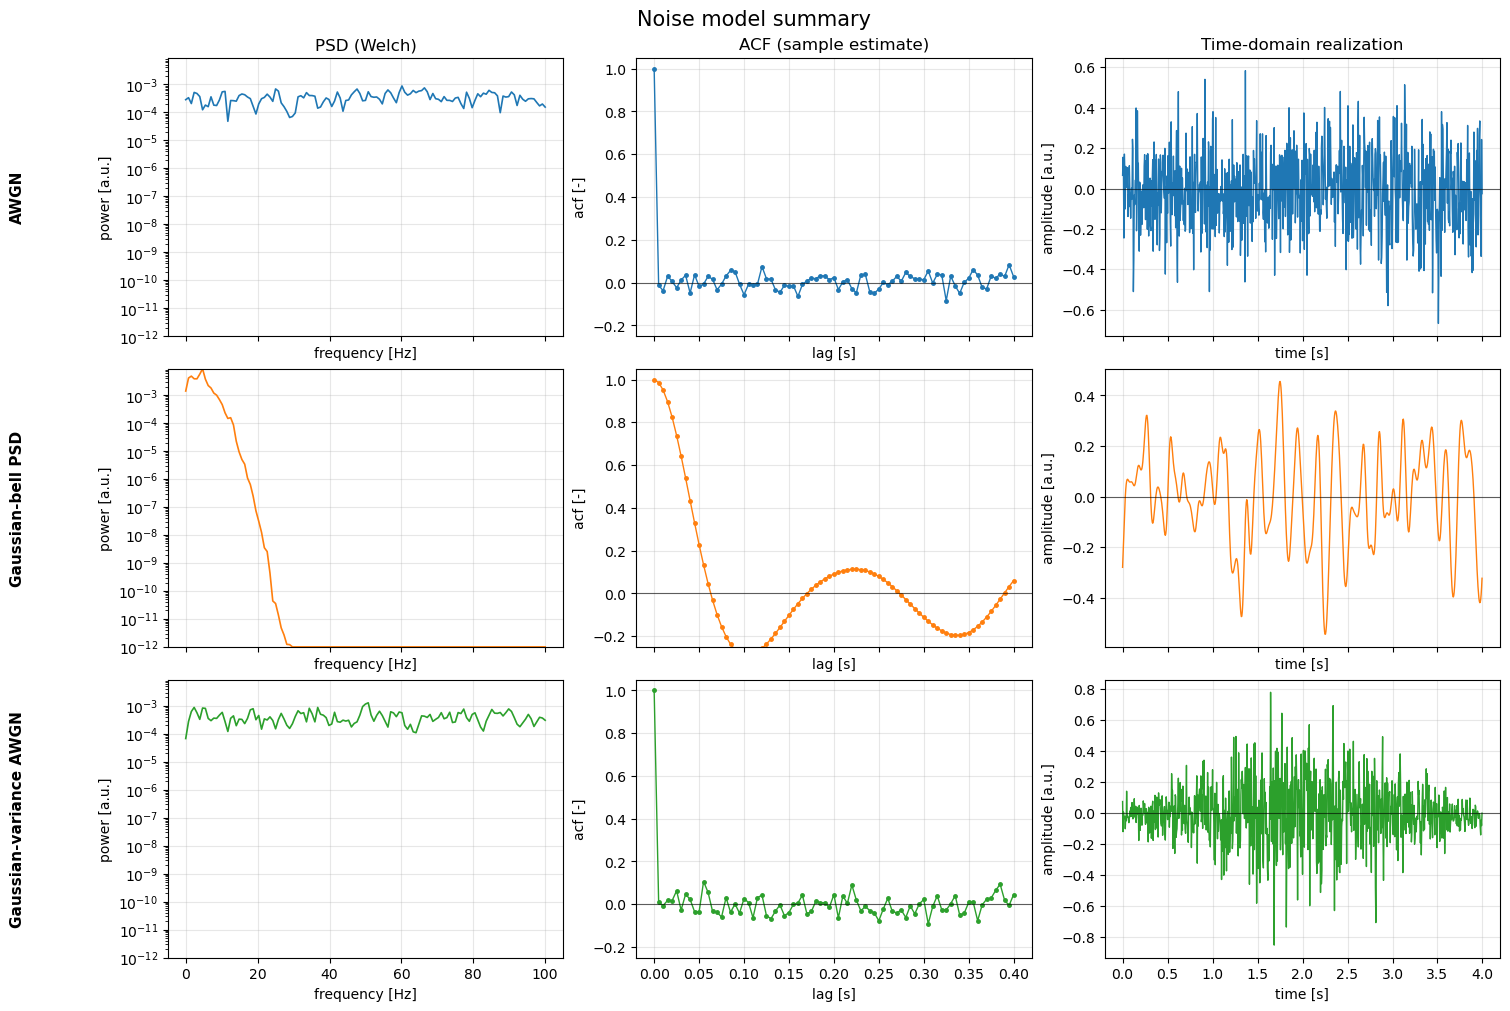

num_samples = 800
target_noise_std = 0.1882
AWGN: empirical std = 0.1850
Gaussian-bell PSD: empirical std = 0.1882
Gaussian-variance AWGN: empirical std = 0.1882


In [3]:
figure, axes = plt.subplots(3, 3, figsize=(15, 10), sharex="col", constrained_layout=True)
column_titles = ["PSD (Welch)", "ACF (sample estimate)", "Time-domain realization"]
row_colors = ["tab:blue", "tab:orange", "tab:green"]

for column_index, title in enumerate(column_titles):
    axes[0, column_index].set_title(title)

plot_rows = []
for (model_name, noise_t), color in zip(noise_models, row_colors, strict=True):
    frequency_hz, psd = estimate_welch_psd(noise_t, sample_rate_hz=sample_rate_hz)
    lag_samples, acf = estimate_sample_acf(noise_t, max_lag_samples=max_lag_samples)
    plot_rows.append(
        {
            "model_name": model_name,
            "noise_t": noise_t,
            "color": color,
            "frequency_hz": frequency_hz,
            "psd": np.maximum(psd, 1e-12),
            "lag_samples": lag_samples,
            "acf": acf,
        }
    )

global_psd_min = min(float(np.min(row["psd"])) for row in plot_rows)
global_psd_max = max(float(np.max(row["psd"])) for row in plot_rows)
global_psd_max = max(global_psd_max, global_psd_min * 10.0)

for row_index, row in enumerate(plot_rows):
    axes[row_index, 0].semilogy(
        row["frequency_hz"],
        row["psd"],
        color=row["color"],
        linewidth=1.2,
    )
    axes[row_index, 0].set_ylim(global_psd_min, global_psd_max)
    axes[row_index, 0].set_ylabel("power [a.u.]")
    axes[row_index, 0].grid(alpha=0.3)

    axes[row_index, 1].plot(
        row["lag_samples"] / sample_rate_hz,
        row["acf"],
        color=row["color"],
        marker="o",
        markersize=2.5,
        linewidth=1.0,
    )
    axes[row_index, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    axes[row_index, 1].set_ylim(-0.25, 1.05)
    axes[row_index, 1].set_ylabel("acf [-]")
    axes[row_index, 1].grid(alpha=0.3)

    axes[row_index, 2].plot(time_s, row["noise_t"], color=row["color"], linewidth=1.0)
    axes[row_index, 2].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    axes[row_index, 2].set_ylabel("amplitude [a.u.]")
    axes[row_index, 2].grid(alpha=0.3)

    axes[row_index, 0].text(
        -0.38,
        0.5,
        row["model_name"],
        transform=axes[row_index, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

for axis in axes[:, 0]:
    axis.set_xlabel("frequency [Hz]")
for axis in axes[:, 1]:
    axis.set_xlabel("lag [s]")
for axis in axes[:, 2]:
    axis.set_xlabel("time [s]")

figure.suptitle("Noise model summary", fontsize=15)
plt.show()

print(f"num_samples = {num_samples}")
print(f"target_noise_std = {target_noise_std:.4f}")
for model_name, noise_t in noise_models:
    print(f"{model_name}: empirical std = {np.std(noise_t, dtype=np.float64):.4f}")
